In [70]:
# Установка библиотеки PyTorch.
!pip3 install torch

In [71]:
import torch
print(torch.__version__)

2.10.0+cpu


# Обучение нейронной сети

## Ирисы Фишера

### Набор данных

 Вы будете работать с известным набором данных для тестирования моделей, чтобы решить задачу классификации [«Ирисы Фишера»](https://ru.wikipedia.org/wiki/%D0%98%D1%80%D0%B8%D1%81%D1%8B_%D0%A4%D0%B8%D1%88%D0%B5%D1%80%D0%B0).

 Набор состоит из информации о 150
 различных цветках ирисов, для каждого из которых известны следующие характеристики:

 1. Длина чашелистика (sepal length), см.
 1. Ширина чашелистика (sepal width), см.
 1. Длина лепестка (petal length), см.
 1. Ширина лепестка (petal width), см.

 Также для каждого из цветков известен один из трёх классов, которому он принадлежит:

 1. Ирис щетинистый (setosa).
 1. Ирис виргинский (virginica).
 1. Ирис разноцветный (versicolor).

 При решении задачи классификации, которая задаётся этим набором данных, нужно научиться по нескольким характеристикам цветка определять, к какому классу он принадлежит.

### Ирисы Фишера в Python

В Python ирисы Фишера доступны в библиотеке `sklearn`:

```
from sklearn import datasets

# в переменную будет сохранён объект «набор данных «Ирисы Фишера»
data = datasets.load_iris()  
```

Чтобы преобразовать набор данных к виду, в котором его будет удобно использовать при создании моделей в PyTorch, необходимо написать:


```
X = torch.tensor(data['data'])
y = torch.tensor(data['target'])
```

В результате в переменной $X$ будет находиться матрица размера $150 \times 4$, в которой каждая строчка соответствует конкретному цветку, а каждая из колонок — одной из его характеристик:

```
tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        ...
        [5.9000, 3.0000, 5.1000, 1.8000]], dtype=torch.float64)
```

В переменной $y$ будет находиться вектор размера $150$. На $i$-й позиции в векторе стоит значение класса для $i$-го цветка из матрицы $X$:


```
tensor([0, 0, 0, 0, ... 2, 2, 2, 2])
```



In [72]:
!pip3 install scikit-learn

In [73]:
import sklearn
from sklearn import datasets

In [74]:
# TODO: Загрузите датасет "Ирисы Фишера"
from sklearn import datasets
# в переменную будет сохранён объект «набор данных «Ирисы Фишера»
data = datasets.load_iris()

In [75]:
# TODO: Преобразуйте обучающую выборку в тензоры Pytorch,
#       в переменную X сохраните признаковое описание объекта - характеристики цветков Ириса,
#       в переменную y сохраните целевую переменную - классы цветков Ириса.
X = torch.tensor(data['data'])
y = torch.tensor(data['target'])

In [76]:
# TODO: С помощью функции train_test_split() из sklearn.model_selection
#       разделите данные на обучающую и тестовую выборку,
#       отправив в тестовую часть 20% данных
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: torch.Size([120, 4])
Размер тестовой выборки: torch.Size([30, 4])


### Что нужно сделать?

В рамках задания вам будет необходимо реализовать нейронную сеть и обучить её для решения задачи классификации цветков из набора данных «Ирисы Фишера».

#### Создание нейронной сети

В этом блокноте ниже уже есть заготовка для решения задания.

В переменную $X$ помещена матрица с характеристиками цветков из набора, в переменную $y$ помещены значения классов, которые необходимо научиться предсказывать.

Вам необходимо заполнить пропущенные места в коде, придумав архитектуру нейронной сети, которая сможет решить поставленную задачу, а также запустить обучение полученной модели. Пропуски, которые необходимо заполнить, помечены комментарием TODO.

In [77]:
from collections import OrderedDict

# TODO: Реализуйте модель нейронной сети и поместите её в эту переменную.
#       В качестве функции активации на последнем слое выберите torch.nn.LogSoftmax.
model = torch.nn.Sequential(
    OrderedDict([
        ("linear_1", torch.nn.Linear(4, 8)),           # первый линейный слой: 4→8
        ("activation_1", torch.nn.ReLU()),              # функция активации
        ("linear_2", torch.nn.Linear(8, 3)),            # второй линейный слой: 8→3
        ("log_softmax", torch.nn.LogSoftmax(dim=1)),    # логарифмический softmax по классам
    ])
)
model = model.to(dtype=X_train.dtype)

model

Sequential(
  (linear_1): Linear(in_features=4, out_features=8, bias=True)
  (activation_1): ReLU()
  (linear_2): Linear(in_features=8, out_features=3, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

In [78]:
model

Sequential(
  (linear_1): Linear(in_features=4, out_features=8, bias=True)
  (activation_1): ReLU()
  (linear_2): Linear(in_features=8, out_features=3, bias=True)
  (log_softmax): LogSoftmax(dim=1)
)

In [79]:
!pip3 install matplotlib

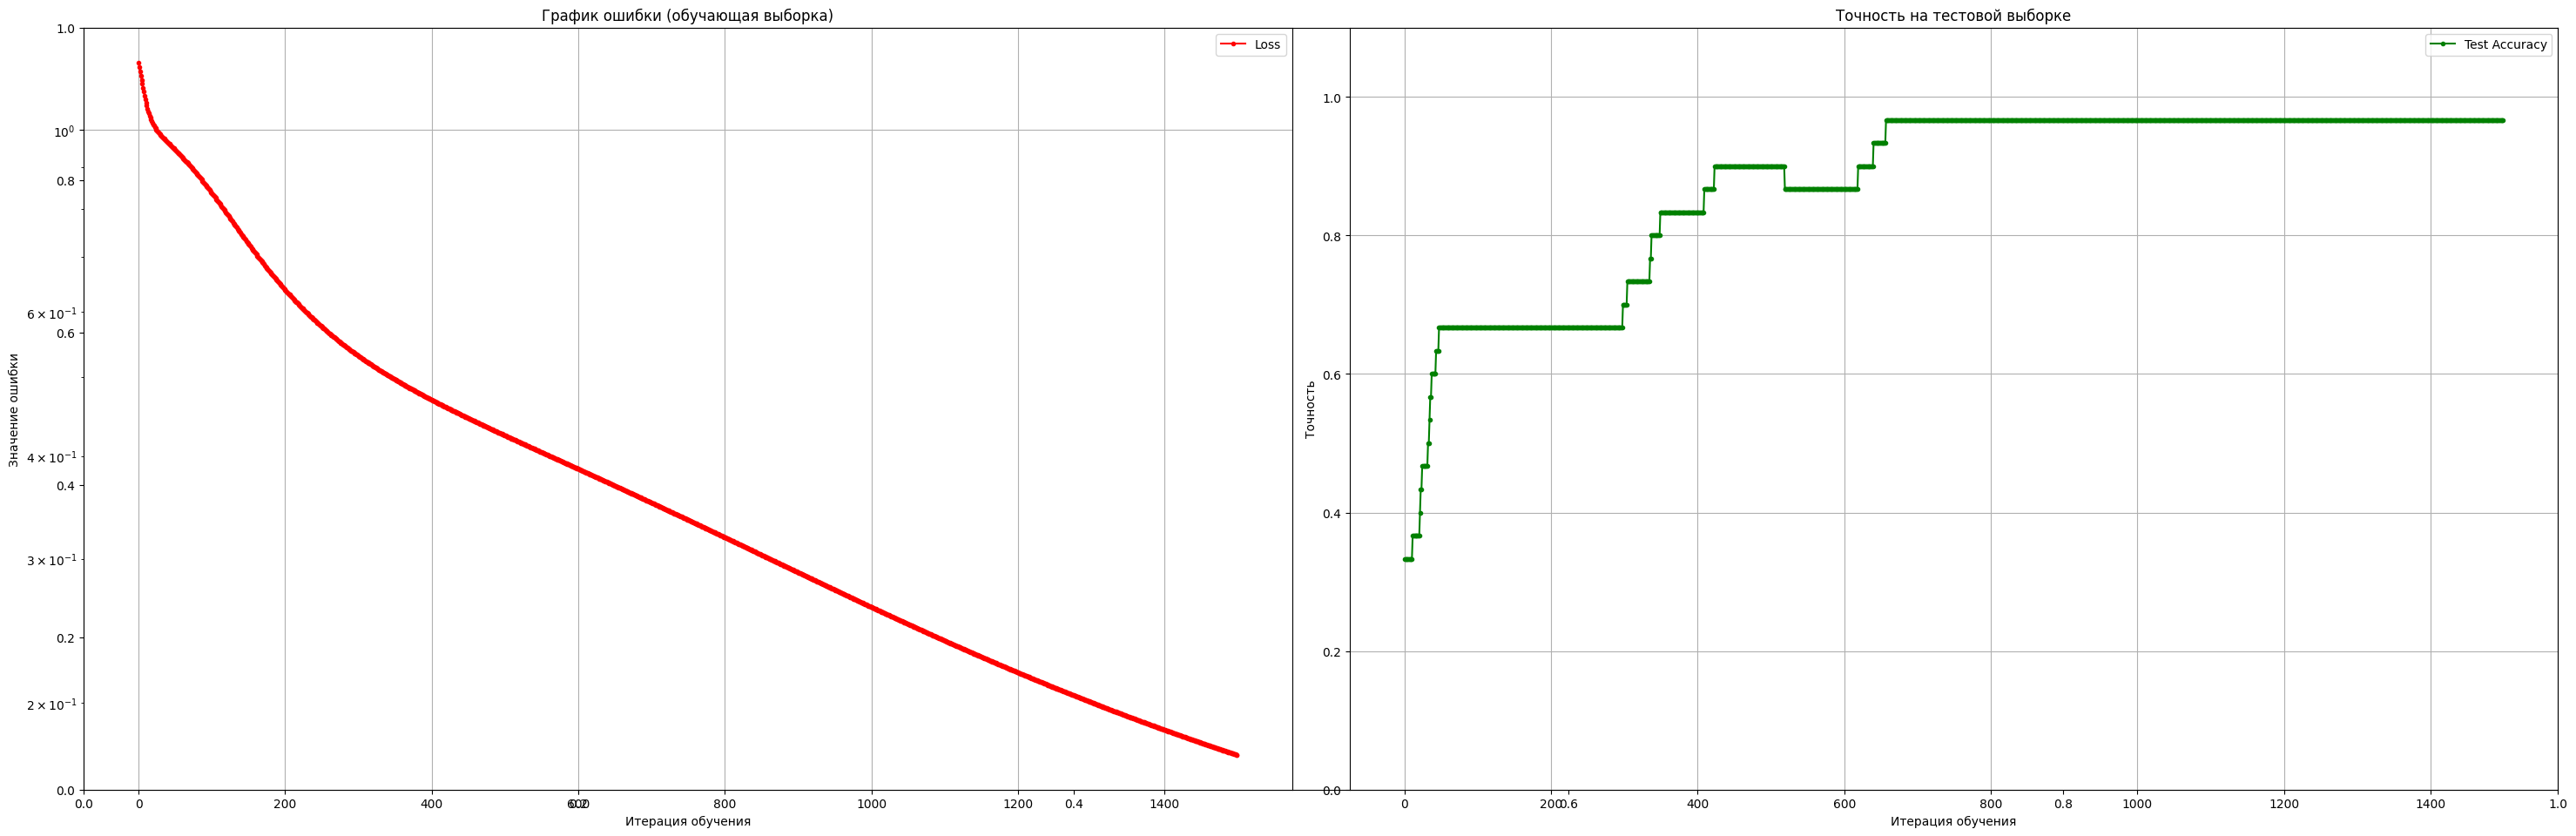

Эпоха 1500: Loss = 0.1729, Test Acc = 96.67%


In [80]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import torch  # Необходимо импортировать torch
%matplotlib inline

# TODO: Подберите число итераций обучения нейронной сети.
#       Значение числа итераций стоит выбрать большим 1000.
num_epochs = 1500

# TODO: Создайте оптимизатор SGD аналогично тому, как он задавался в лекции.
#       Не забудьте передать в него model.parameters().
#       В качестве величины шага обучения (параметр lr) возьмите значение 0.01.
optimizer = torch.optim.SGD(
    model.parameters(),  # все обучаемые параметры модели
    lr=0.01              # шаг обучения
)

# TODO: Задайте функцию потерь. В нашем случае это должна быть torch.nn.NLLLoss.
loss_fn = torch.nn.NLLLoss()

losses = []
test_accuracy_history = []

for epoch in range(1, num_epochs + 1):
    # Обнуляем градиенты перед новым шагом
    optimizer.zero_grad()

    # Прямой проход: получаем предсказания модели
    pred = model(X_train)

    # Вычисляем функцию потерь на обучающей выборке
    loss = loss_fn(pred, y_train)

    # Обратный проход: вычисляем градиенты
    loss.backward()

    # Шаг оптимизации: обновляем веса модели
    optimizer.step()

    losses.append(loss.item())

    with torch.no_grad():
        test_preds = model(X_test)
        accuracy = (test_preds.argmax(dim=1) == y_test).float().mean()
        test_accuracy_history.append(accuracy.item())

    if epoch % 100 == 0:
        clear_output(True)
        fig, ax = plt.subplots(figsize=(30, 10))

        # График ошибки
        plt.subplot(1, 2, 1)
        plt.title("График ошибки (обучающая выборка)")
        plt.plot(losses, ".-",color="red", label="Loss")
        plt.xlabel("Итерация обучения")
        plt.ylabel("Значение ошибки")
        plt.yscale("log")
        plt.grid()
        plt.legend()

        # График точности на тесте
        plt.subplot(1, 2, 2)
        plt.title("Точность на тестовой выборке")
        plt.plot(test_accuracy_history, ".-", color="green", label="Test Accuracy")
        plt.xlabel("Итерация обучения")
        plt.ylabel("Точность")
        plt.ylim(0, 1.1)
        plt.grid()
        plt.legend()

        plt.tight_layout()
        plt.show()

        print(f"Эпоха {epoch}: Loss = {loss.item():.4f}, Test Acc = {test_accuracy_history[-1]:.2%}")

## Получение предсказания на тестовой выборке
В качестве ответа присвойте переменной y_pred список предсказанных классов для тестовыой выборки


In [81]:
# Модель для каждого объекта из тестовых данных возвращает вектор из 3-х численных значений,
# каждое из которых является логарифмом вероятности принадлежности объекта конкретному классу.
log_probs = model(X_test)

# Преобразуем в вероятности (опционально, для интерпретации)
pred_class_probs = log_probs.exp()

# Выбираем класс с максимальной вероятностью для каждого объекта
pred_class = torch.argmax(log_probs, dim=1)

print(f"Предсказанные классы для тестовой выборки:\n{pred_class}")
print(f"Истинные классы:\n{y_test}")

Предсказанные классы для тестовой выборки:
tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])
Истинные классы:
tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])


#### Ответ на тестовой выборке

In [82]:
print(pred_class)

tensor([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 1, 2,
        2, 1, 1, 0, 2, 0])


Посчитайте точность предсказаний, как долю верно предсказанных ответов

In [83]:
# ТОDO: посчитайте точность предсказаний
# Способ 1: вручную
correct_predictions = (pred_class == y_test).sum().item()
total_samples = y_test.shape[0]
test_accuracy = correct_predictions / total_samples

print(f"\nТочность на тестовой выборке: {test_accuracy:.2%} ({correct_predictions}/{total_samples})")

# Способ 2: через mean() (более компактно)
accuracy_alt = (pred_class == y_test).float().mean().item()
print(f"Точность (альтернативный расчёт): {accuracy_alt:.2%}")


Точность на тестовой выборке: 96.67% (29/30)
Точность (альтернативный расчёт): 96.67%
